# **Metodología CRISP-DM aplicada a WeatherAUS**

Autores: Álvaro Flores - Aurora Mansilla

## **1. Business Understanding**

Este informe tiene como objetivo aplicar las tres primeras fases de la metodología CRISP-DM sobre el dataset climático de Australia (weatherAUS.xlsx/csv).

Las fases abordadas son:

- Business Understanding
- Data Understanding
- Data Preparation

El propósito del análisis es preparar los datos para futuros modelos supervisados y no supervisados relacionados con predicción climática, específicamente la variable objetivo

### 1. **Comprensión del negocio**

El análisis de datos meteorológicos es fundamental para anticipar fenómenos climáticos y apoyar la toma de decisiones en múltiples sectores:

- Agricultura
- Transporte
- Prevención de riesgos
- Turismo

En este caso, el objetivo principal es preparar adecuadamente los datos para construir modelos capaces de:

- Predecir si lloverá al día siguiente
- Detectar patrones climáticos
- Identificar comportamientos meteorológicos relevantes
- Encontrar insights útiles para el negocio

### 1.2. **Objetivos del proyecto**

**Objetivo general**

Preparar y transformar los datos climáticos de Australia utilizando la metodología CRISP-DM para su uso en modelos de Machine Learning.

**Objetivos específicos**

- Analizar la calidad de los datos
- Detectar valores nulos y anomalías
- Aplicar transformaciones de datos
- Reducir problemas de overfitting y underfitting
- Codificar variables categóricas
- Escalar variables numéricas
- Preparar datasets para aprendizaje supervisado y no supervisado
- Obtener insights relevantes para el negocio

### 1.3. **Problema de negocio**

Las condiciones climáticas son variables complejas que afectan múltiples procesos económicos y sociales. La predicción incorrecta de eventos climáticos puede generar:

- Pérdidas agrícolas
- Problemas logísticos
- Riesgos para la población
- Mala planificación operativa

Por ello, disponer de datos correctamente preparados permite generar modelos predictivos más precisos y confiables.

# **2. Data Understanding**



In [ ]:
#2.1. Importación de librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
#2.2. Cargar dataset

df = pd.read_csv('weatherAUS.csv')

# Visualizar primeras filas

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [ ]:
#2.3. Dimensiones del dataset

print(df.shape)

(142193, 24)


In [ ]:
#2.4. Información general

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null

In [ ]:
#2.5. Descripción estadística

df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


In [ ]:
#3.6. Valores nulos por columna

df.isnull().sum()

,0
Date,0
Location,0
MinTemp,637
MaxTemp,322
Rainfall,1406
Evaporation,60843
Sunshine,67816
WindGustDir,9330
WindGustSpeed,9270
WindDir9am,10013


Se puede visualizar una considerable cantidad de valores nulos, por lo cual se recomienda limpieza del dataset para obtener datos más limpios y predicciones optimizadas.

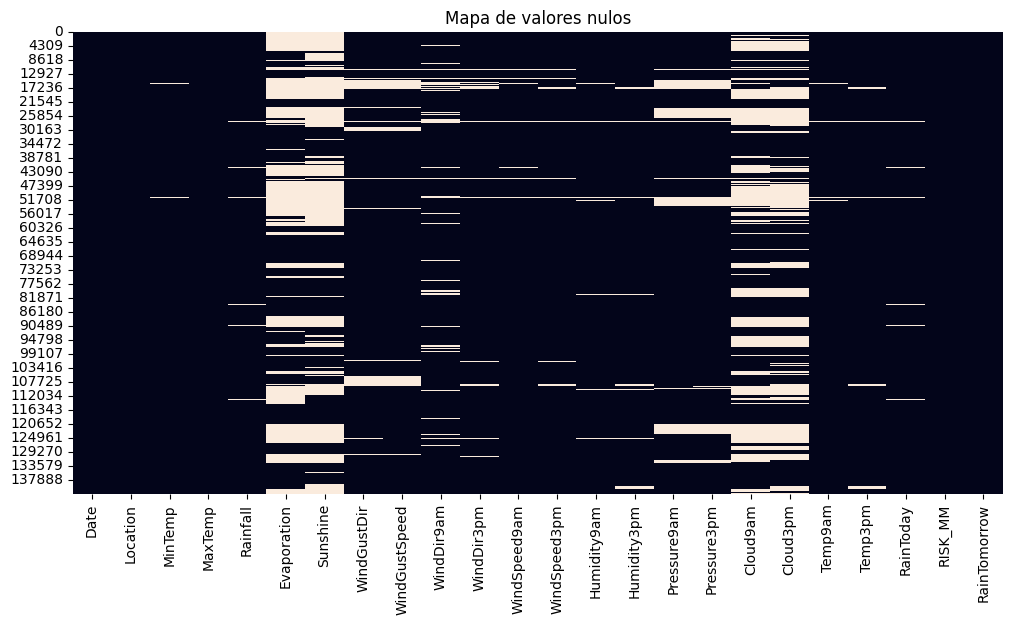

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Mapa de valores nulos')
plt.show()

El heatmap mostrado previamente deja en evidencia la cantidad de valores nulos del dataset, las áreas más claras son dichos valores, los cuales pueden verse en diversas partes del mapa.

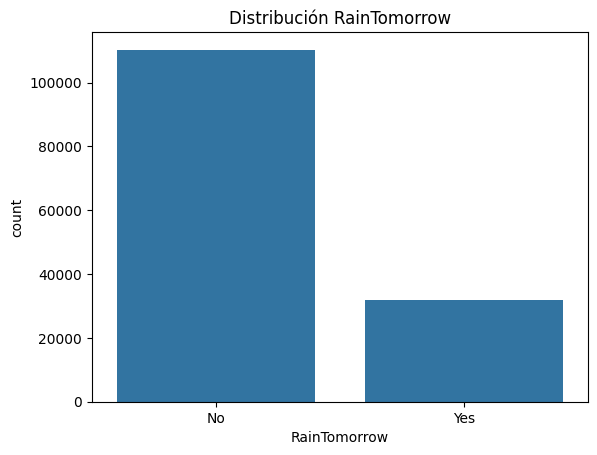

In [ ]:
#2.7. Distribución de la variable objetivo
sns.countplot(x='RainTomorrow', data=df)
plt.title('Distribución RainTomorrow')
plt.show()

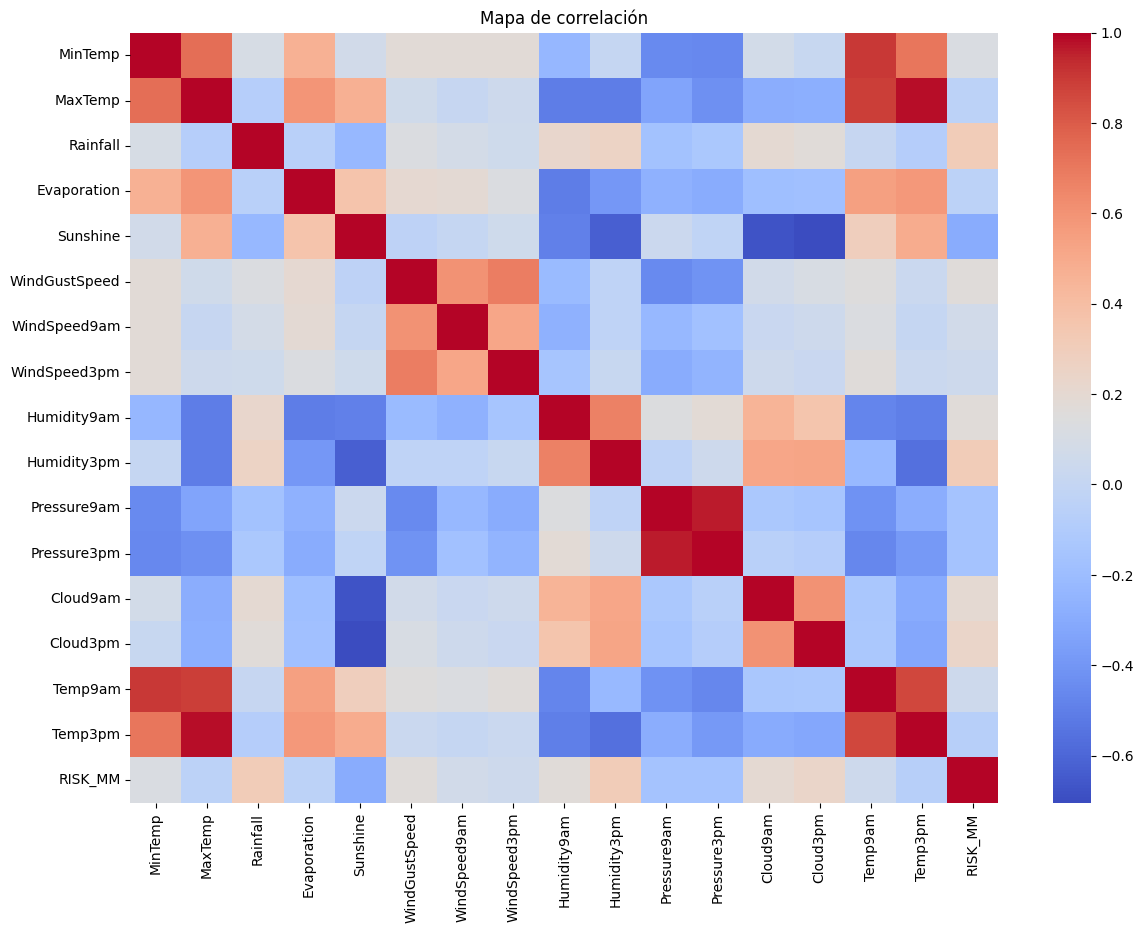

In [ ]:
#2.8. Correlación entre variables numéricas

plt.figure(figsize=(14,10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, cmap='coolwarm')
plt.title('Mapa de correlación')
plt.show()

- Temperaturas máximas y mínimas presentan alta correlación.
- Humedad y presión atmosférica muestran relación con eventos de lluvia.
- Variables como Rainfall y Humidity pueden ser importantes para predicción.

## **Bitácora de Decisiones** (Va al final)

| Problema Detectado | Intento Fallido | Solución Final Aplicada | Justificación de negocio |
|---|---|---|---|
Faltaba orden para visualizar los datos|Al inicio había que ordenar la información|Se crearon heatmaps y gráficos para visualizar la información|Al tener más organizada la información se pueden tener mejores predicciones para el negocio|
Se desconocía la variabe objetivo|Sin variable objetivo no hay un camino a seguir con los datos|Se determinó la variable objetivo a trabajar|De este modo todo el colab sigue un propósito con los datos del dataset